In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

data1 = np.loadtxt("data/3/1.txt")
data2 = np.loadtxt("data/3/6.txt")
data3 = np.loadtxt("data/3/3.txt")
data4 = np.loadtxt("data/3/4.txt")

In [2]:
def histogram(data):
    g = int(1 + np.log2(len(data)))  # Правило Стерджеса
    
    counts, bin_edges = np.histogram(data, bins=g)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    relative_freq = counts / len(data)
    
    return g, counts, bin_edges, bin_centers, relative_freq


In [3]:
def p_norm(x, mu, sigma):
    return (1 / (np.sqrt(2 * np.pi * sigma**2))) * np.exp(-((x - mu)**2) / (2 * sigma**2))

def p_exp(x, lambd):
    return lambd * np.exp(-lambd * x)

def p_uni(x, a, b):
    return np.where((x >= a) & (x <= b), 1 / (b - a), 0)

def P_norm(x, mu, sigma):
    return 0.5 * (1 + math.erf((x - mu) / (sigma * np.sqrt(2))))

def P_exp(x, lambd):
    return 1 - np.exp(-lambd * x)

def P_uni(x, a, b):
    return np.where(x < a, 0, np.where(x > b, 1, (x - a) / (b - a)))

def normal_params_and_freq(data, bin_edges, n):
    mu = np.mean(data)
    sigma = np.std(data, ddof=1)  # несмещенная оценка
    params = (mu, sigma)
    exp_freq = []
    for i in range(len(bin_edges) - 1):
        p_i = P_norm(bin_edges[i+1], mu, sigma) - P_norm(bin_edges[i], mu, sigma)
        exp_freq.append(p_i * n)
        
    return params, exp_freq

def exponential_params_and_freq(data, bin_edges, n):
    lambd = 1 / np.mean(data)
    params = (lambd,)
    exp_freq = []
    for i in range(len(bin_edges) - 1):
        p_i = P_exp(bin_edges[i+1], lambd) - P_exp(bin_edges[i], lambd)
        exp_freq.append(p_i * n)
        
    return params, exp_freq

def uniform_params_and_freq(data, bin_edges, n):
    a = np.min(data)
    b = np.max(data)
    params = (a, b)
    
    exp_freq = []
    for i in range(len(bin_edges) - 1):
        p_i = P_uni(bin_edges[i+1], a, b) - P_uni(bin_edges[i], a, b)
        exp_freq.append(p_i * n)
        
    return params, exp_freq

In [4]:
from scipy.stats import chi2


def chi_squared_test(data, dist_type, alpha=0.05):
    g, counts, bin_edges, _, _ = histogram(data)
    n = len(data)
    if dist_type == "normal":
        params, exp_freq = normal_params_and_freq(data, bin_edges, n)
    elif dist_type == "exponential":
        params, exp_freq = exponential_params_and_freq(data, bin_edges, n)
    elif dist_type == "uniform":
        params, exp_freq = uniform_params_and_freq(data, bin_edges, n)
        
    chi2_stat = 0
    for i in range(len(counts)):
        # Проверка, чтобы избежать деления на ноль
        if exp_freq[i] > 0:
            chi2_stat += (counts[i] - exp_freq[i])**2 / exp_freq[i]
        # Если теоретическая частота равна нулю, но наблюдаемая ненулевая, 
        # это означает сильное расхождение с теоретическим распределением
        elif counts[i] > 0:
            chi2_stat += float('inf')
    
    # Степени свободы: k = число групп - число оцененных параметров - 1
    k = len(counts) - (2 if dist_type == "normal" else 1) - 1
    
    # Проверка, что количество степеней свободы положительно
    if k <= 0:
        k = 1
    
    # Критическое значение
    critical_value = chi2.ppf(1 - alpha, k)
    
    # Результат теста
    result = (chi2_stat < critical_value)
    
    return chi2_stat, critical_value, k, result, params

In [5]:
dist_type = ["normal", "exponential", "uniform"]
chi2_stat, critical_value, k, result, _ = chi_squared_test(data1, dist_type[0])
print(f'1.txt {dist_type[0]} check')
print("Хи квадрат = ", chi2_stat)
print("Критическое значение = ", critical_value)
print("Степени свободы = ", k)
print("Реузультат проверки:  ", result, '\n')


chi2_stat, critical_value, k, result, params = chi_squared_test(data1, dist_type[1])
print(f'1.txt {dist_type[1]} check')
print("Хи квадрат = ", chi2_stat)
print("Критическое значение = ", critical_value)
print("Степени свободы = ", k)
print("Реузультат проверки:  ", result, '\n')

chi2_stat, critical_value, k, result, params = chi_squared_test(data2, dist_type[1])
print(f'6.txt {dist_type[1]} check')
print("Хи квадрат = ", chi2_stat)
print("Критическое значение = ", critical_value)
print("Степени свободы = ", k)
print("Реузультат проверки:  ", result, '\n')

chi2_stat, critical_value, k, result, params = chi_squared_test(data2, dist_type[2])
print(f'6.txt {dist_type[2]} check')
print("Хи квадрат = ", chi2_stat)
print("Критическое значение = ", critical_value)
print("Степени свободы = ", k)
print("Реузультат проверки:  ", result, '\n')

chi2_stat, critical_value, k, result, params = chi_squared_test(data3, dist_type[1])
print(f'3.txt {dist_type[1]} check')
print("Хи квадрат = ", chi2_stat)
print("Критическое значение = ", critical_value)
print("Степени свободы = ", k)
print("Реузультат проверки:  ", result, '\n')

chi2_stat, critical_value, k, result, params = chi_squared_test(data3, dist_type[0])
print(f'3.txt {dist_type[0]} check')
print("Хи квадрат = ", chi2_stat)
print("Критическое значение = ", critical_value)
print("Степени свободы = ", k)
print("Реузультат проверки:  ", result, '\n')

chi2_stat, critical_value, k, result, params = chi_squared_test(data4, dist_type[0])
print(f'4.txt {dist_type[0]} check')
print("Хи квадрат = ", chi2_stat)
print("Критическое значение = ", critical_value)
print("Степени свободы = ", k)
print("Реузультат проверки:  ", result, '\n')

chi2_stat, critical_value, k, result, params = chi_squared_test(data4, dist_type[2])
print(f'4.txt {dist_type[2]} check')
print("Хи квадрат = ", chi2_stat)
print("Критическое значение = ", critical_value)
print("Степени свободы = ", k)
print("Реузультат проверки:  ", result, '\n')

1.txt normal check
Хи квадрат =  1.7408006608729338
Критическое значение =  7.814727903251179
Степени свободы =  3
Реузультат проверки:   True 

1.txt exponential check
Хи квадрат =  52.44430235443253
Критическое значение =  9.487729036781154
Степени свободы =  4
Реузультат проверки:   False 

6.txt exponential check
Хи квадрат =  4.732717585278492
Критическое значение =  12.591587243743977
Степени свободы =  6
Реузультат проверки:   True 

6.txt uniform check
Хи квадрат =  162.0
Критическое значение =  12.591587243743977
Степени свободы =  6
Реузультат проверки:   False 

3.txt exponential check
Хи квадрат =  8.37159880666618
Критическое значение =  9.487729036781154
Степени свободы =  4
Реузультат проверки:   True 

3.txt normal check
Хи квадрат =  11.219878134023103
Критическое значение =  7.814727903251179
Степени свободы =  3
Реузультат проверки:   False 

4.txt normal check
Хи квадрат =  8.004307044234945
Критическое значение =  11.070497693516351
Степени свободы =  5
Реузультат 

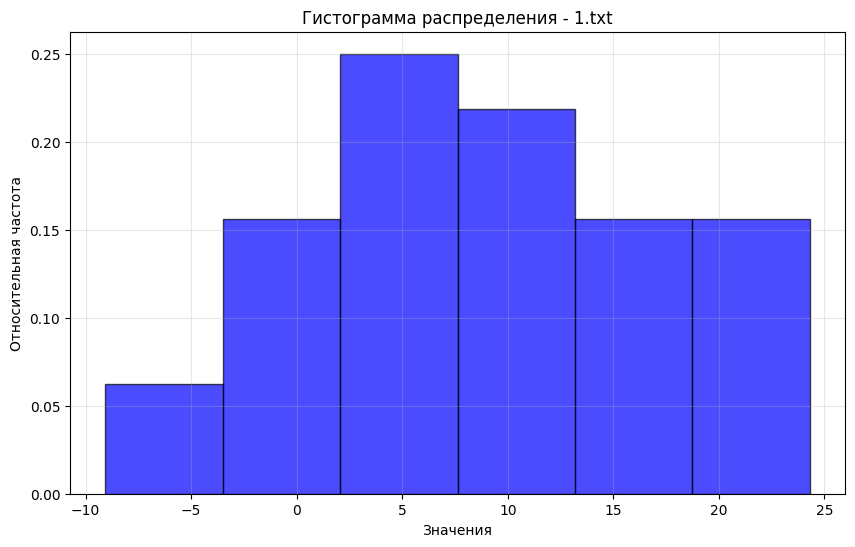

In [6]:

g, counts, bin_edges, bin_centers, relative_freq = histogram(data1)

plt.figure(figsize=(10, 6))
plt.bar(bin_centers, relative_freq, width=bin_centers[1]-bin_centers[0], alpha=0.7, color='blue', edgecolor='black')
plt.title(f'Гистограмма распределения - 1.txt')
plt.xlabel('Значения')
plt.ylabel('Относительная частота')
plt.grid(True, alpha=0.3)
plt.show()

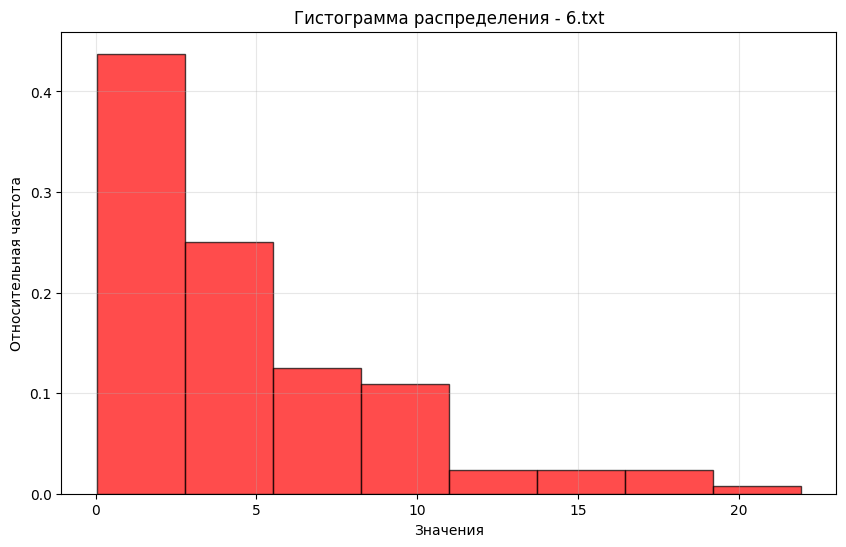

In [7]:
g, counts, bin_edges, bin_centers, relative_freq = histogram(data2)

plt.figure(figsize=(10, 6))
plt.bar(bin_centers, relative_freq, width=bin_centers[1]-bin_centers[0], alpha=0.7, color='red', edgecolor='black')
plt.title(f'Гистограмма распределения - 6.txt')
plt.xlabel('Значения')
plt.ylabel('Относительная частота')
plt.grid(True, alpha=0.3)
plt.show()

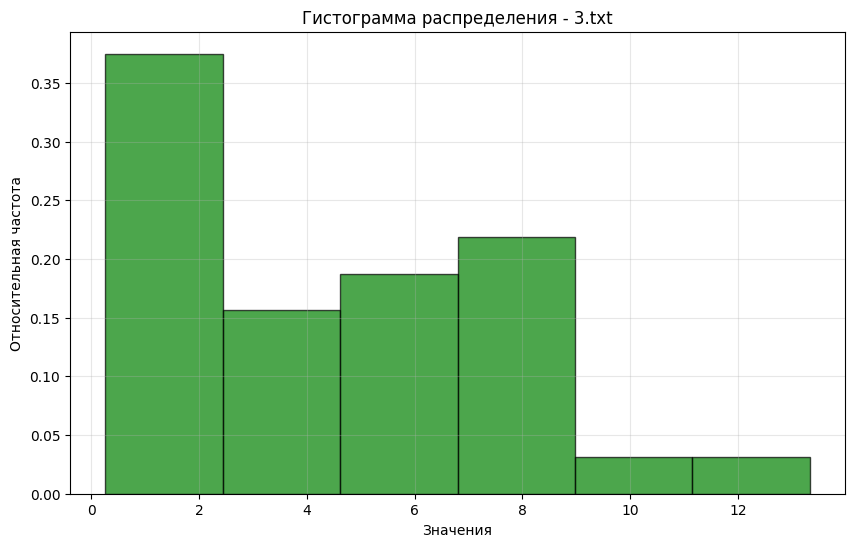

In [8]:
g, counts, bin_edges, bin_centers, relative_freq = histogram(data3)

plt.figure(figsize=(10, 6))
plt.bar(bin_centers, relative_freq, width=bin_centers[1]-bin_centers[0], alpha=0.7, color='green', edgecolor='black')
plt.title(f'Гистограмма распределения - 3.txt')
plt.xlabel('Значения')
plt.ylabel('Относительная частота')
plt.grid(True, alpha=0.3)
plt.show()

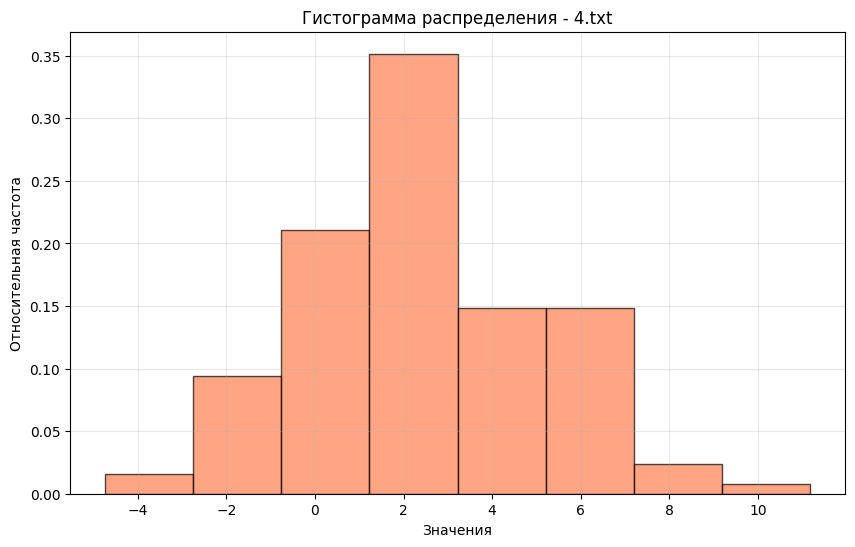

In [9]:
g, counts, bin_edges, bin_centers, relative_freq = histogram(data4)

plt.figure(figsize=(10, 6))
plt.bar(bin_centers, relative_freq, width=bin_centers[1]-bin_centers[0], alpha=0.7, color='coral', edgecolor='black')
plt.title(f'Гистограмма распределения - 4.txt')
plt.xlabel('Значения')
plt.ylabel('Относительная частота')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
from scipy import stats
def anamorphosis(data, dist_type):
    # Вычисляем гистограмму
    _, counts, bin_edges, bin_centers, relative_freq = histogram(data)
    
    # Фильтруем нулевые частоты
    non_zero = relative_freq > 0
    x = bin_centers[non_zero]
    y = relative_freq[non_zero]
    
    if dist_type == "normal":
        # Анаморфоза нормального распределения: ln(p(x)) = -1/(2*sigma^2)*(x-mu)^2 + const
        mu = np.mean(data)
        y_transformed = np.log(y)
        x_transformed = (x - mu)**2
        
        # Линейная регрессия
        slope, intercept, r_value, _, _ = stats.linregress(x_transformed, y_transformed)
        
        # Вычисляем R^2
        r_squared = r_value**2
        
        # Оценка параметров
        sigma = np.sqrt(-1/(2*slope)) if slope < 0 else np.nan
        
        return r_squared, (mu, sigma), x_transformed, y_transformed, slope, intercept
        
    elif dist_type == "exponential":
        # Анаморфоза экспоненциального распределения: ln(p(x)) = -lambda*x + const
        y_transformed = np.log(y)
        x_transformed = x
        
        # Линейная регрессия
        slope, intercept, r_value, _, _ = stats.linregress(x_transformed, y_transformed)
        
        # Вычисляем R^2
        r_squared = r_value**2
        
        # Оценка параметров
        lambd = -slope
        
        return r_squared, (lambd,), x_transformed, y_transformed, slope, intercept
        
    elif dist_type == "uniform":
        # Для равномерного распределения плотность постоянна
        y_transformed = y
        x_transformed = x
        
        # Вычисляем R^2 для горизонтальной линии
        mean_y = np.mean(y_transformed)
        ss_res = np.sum((y_transformed - mean_y)**2)
        ss_tot = np.sum((y_transformed - np.mean(y_transformed))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        # Оценка параметров
        a = np.min(data)
        b = np.max(data)
        
        return r_squared, (a, b), x_transformed, y_transformed, 0, mean_y

In [11]:
def plot_all_anamorphosis_for_file(data, filename):
    # Список типов распределений и их параметров
    distributions = [
        ("normal", "Нормальное распределение",),
        
        ("exponential", "Экспоненциальное распределение"),
        
        ("uniform", "Равномерное распределение")
    ]
    
    # Создаем фигуру с 3 подграфиками
    plt.figure(figsize=(20, 6))
    
    for i, (dist_type, title) in enumerate(distributions, 1):
        # Вычисляем данные для анаморфозы
        r_squared, params, x_trans, y_trans, slope, intercept = anamorphosis(data, dist_type)
        
        # Сортируем данные по x для правильного соединения точек
        sorted_indices = np.argsort(x_trans)
        x_trans_sorted = x_trans[sorted_indices]
        y_trans_sorted = y_trans[sorted_indices]
        
        # Создаем подграфик
        plt.subplot(1, 3, i)
        
        # Отображаем точки данных
        plt.plot(x_trans_sorted, y_trans_sorted, 'o-', alpha=0.6, linewidth=1.5, 
                 markersize=6, label='Экспериментальные данные')
        
        # Рисуем линейный тренд
        if dist_type in ["normal", "exponential"]:
            x_line = np.linspace(min(x_trans), max(x_trans), 100)
            y_line = slope * x_line + intercept
            plt.plot(x_line, y_line, 'r-', linewidth=2, 
                     label=f'Линейный тренд (R² = {r_squared:.4f})')
        else:
            plt.axhline(y=intercept, color='r', linestyle='-', linewidth=2,
                       label=f'Горизонтальная линия (R² = {r_squared:.4f})')
        
        plt.title(f'{title}\nдля файла {filename}', fontsize=14)
        plt.legend(fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()

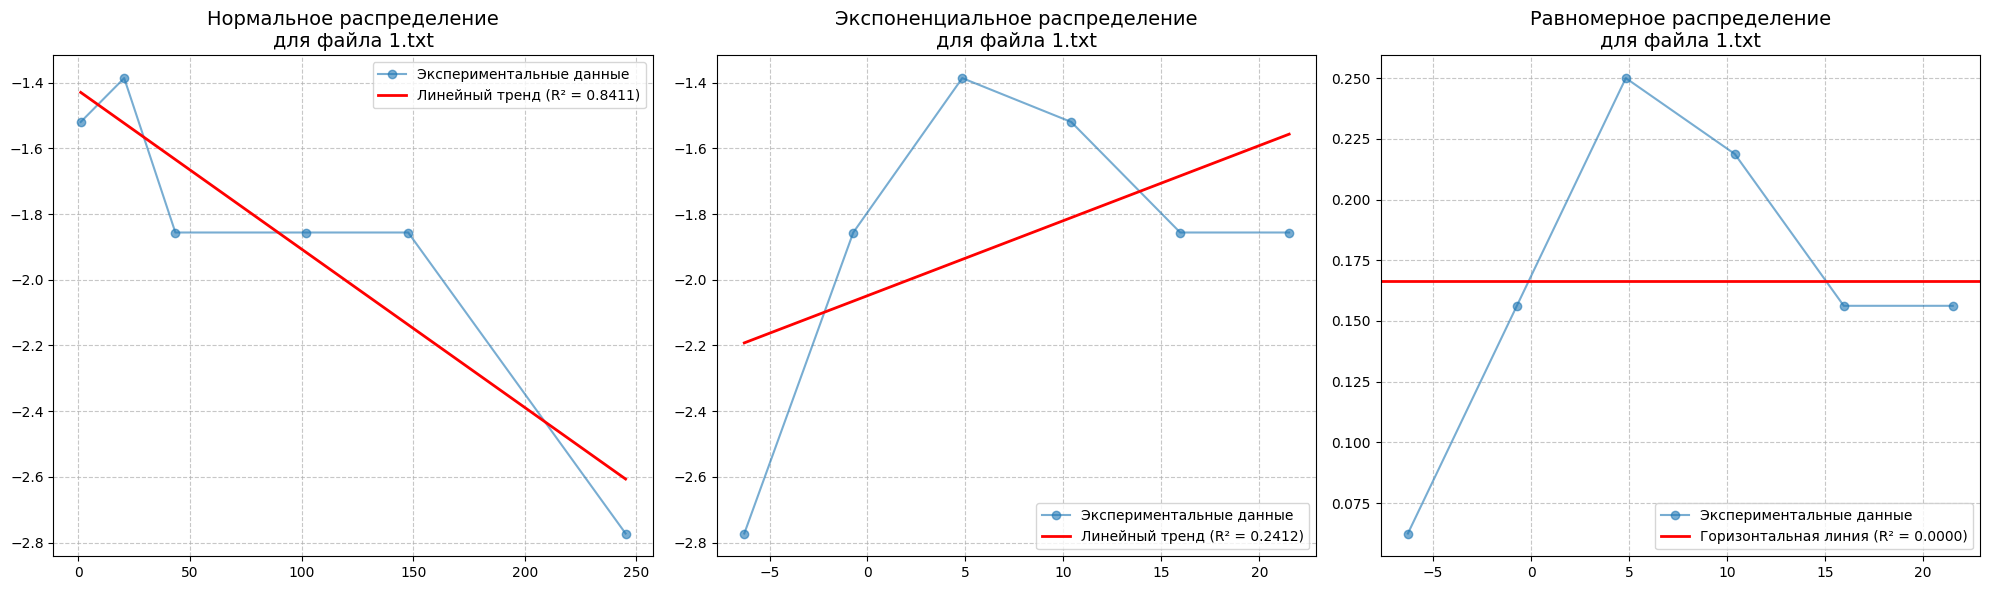

In [12]:
plot_all_anamorphosis_for_file(data1, "1.txt")

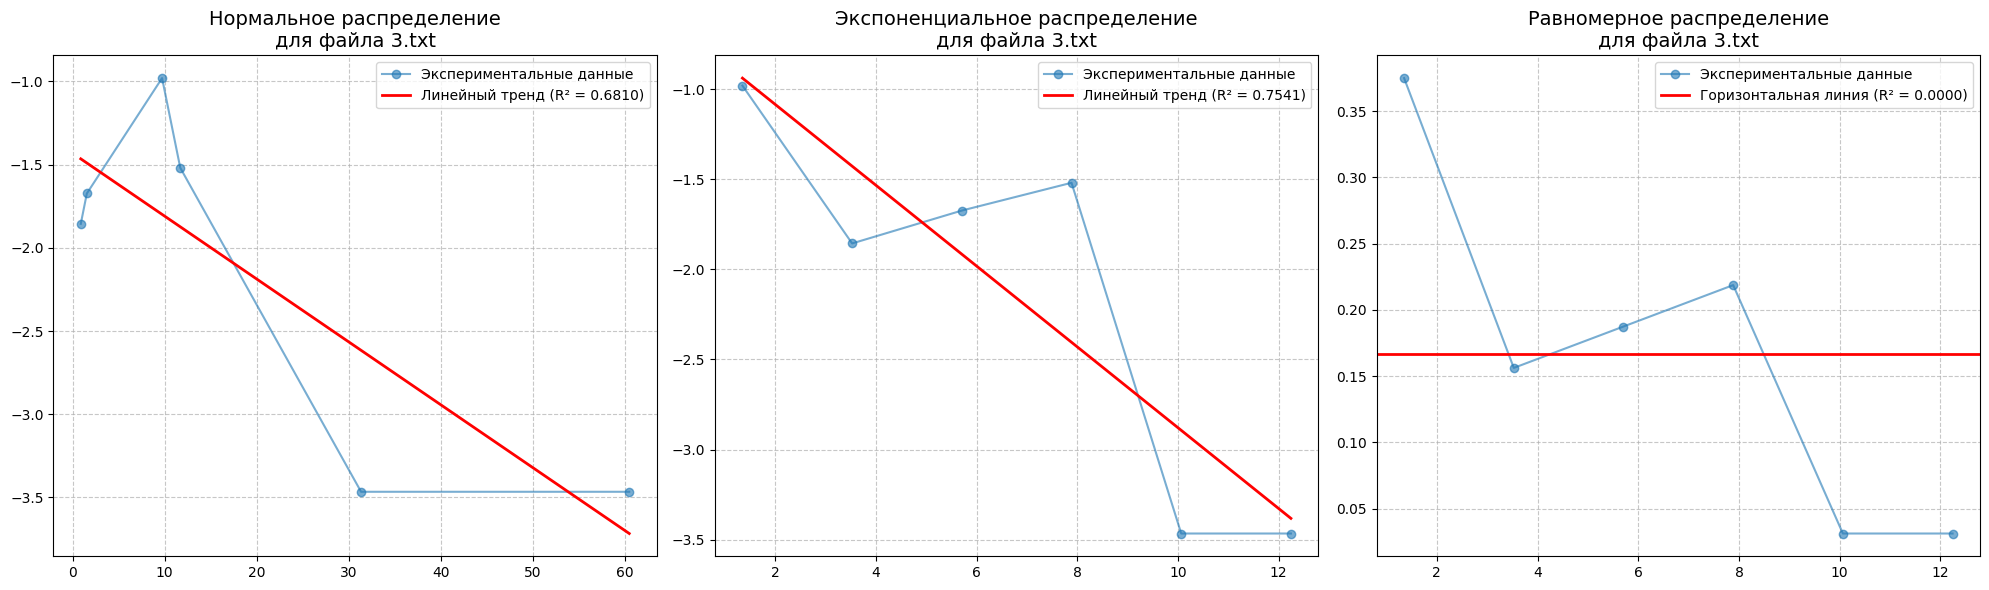

In [13]:
plot_all_anamorphosis_for_file(data3, "3.txt")

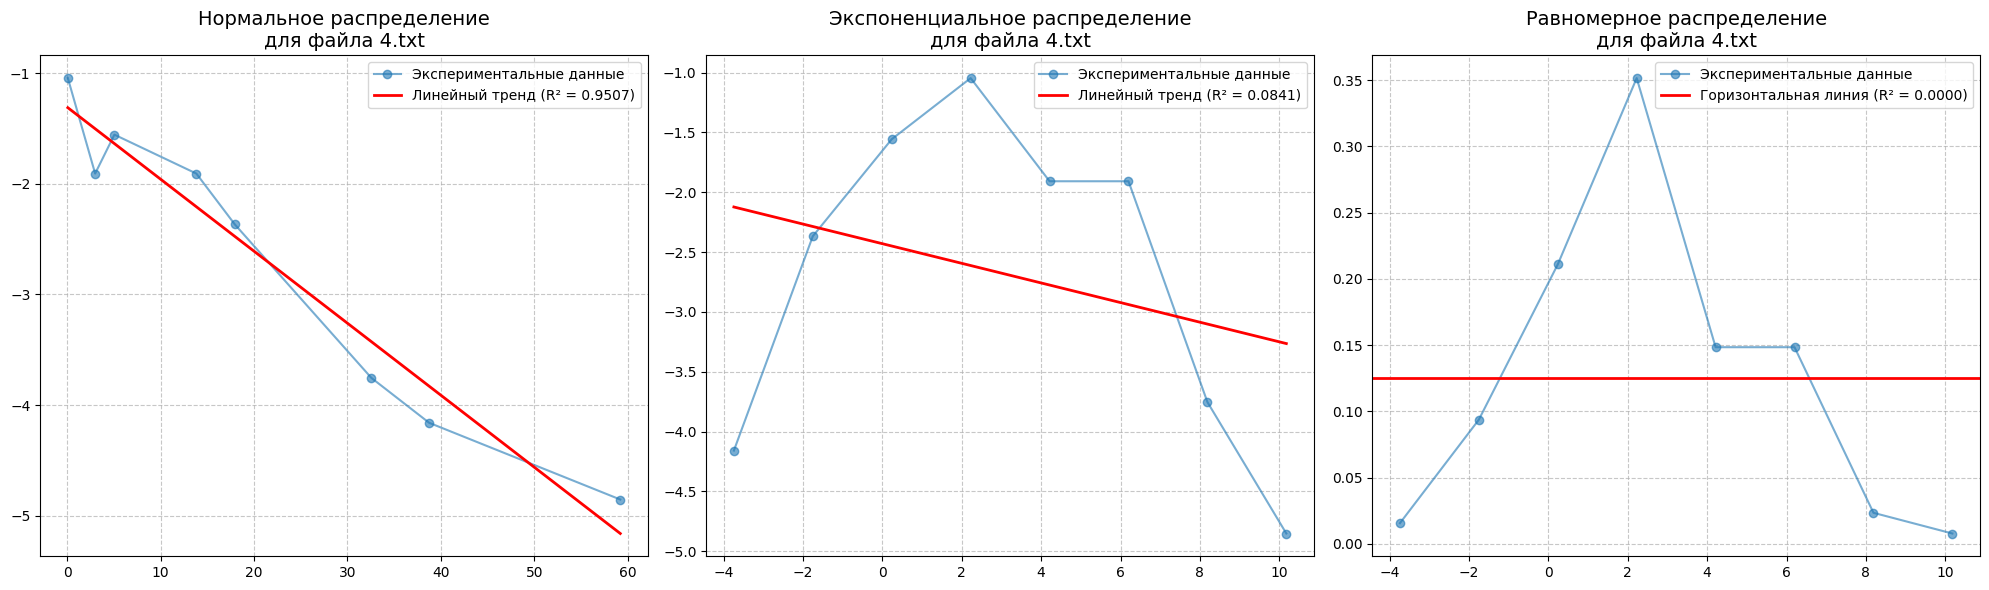

In [14]:
plot_all_anamorphosis_for_file(data4, "4.txt")

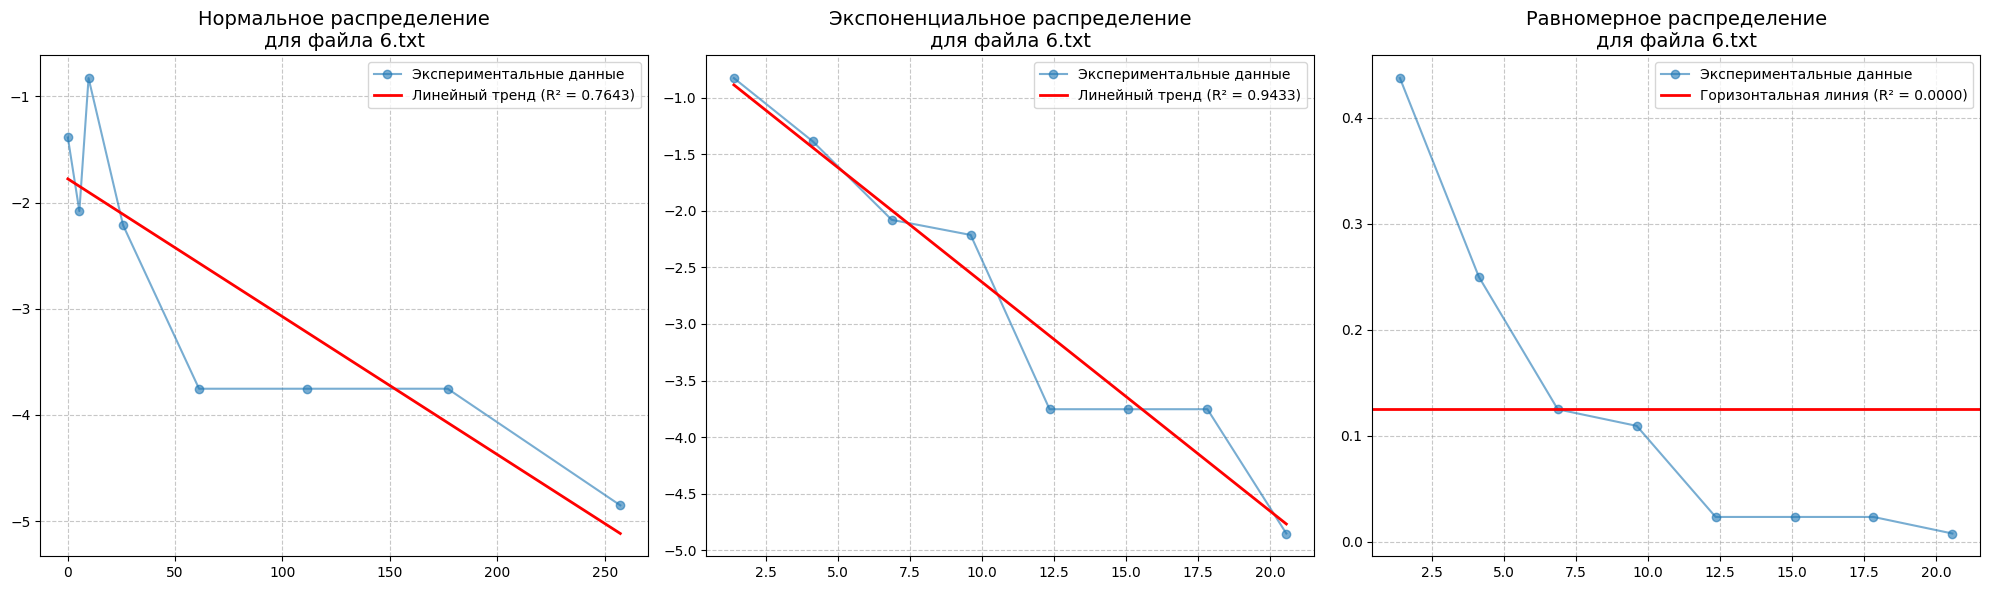

In [15]:
plot_all_anamorphosis_for_file(data2, "6.txt")

In [16]:
def anamorphosis_print_params(data, dist_type):
    # Вычисляем гистограмму
    _, counts, bin_edges, bin_centers, relative_freq = histogram(data)
    
    # Фильтруем нулевые частоты
    non_zero = relative_freq > 0
    x = bin_centers[non_zero]
    y = relative_freq[non_zero]
    
    if dist_type == "normal":
        # Анаморфоза нормального распределения: ln(p(x)) = -1/(2*sigma^2)*(x-mu)^2 + const
        mu = np.mean(data)  # Несмещенная оценка мат. ожидания
        sigma_var = np.var(data, ddof=1)  # Несмещенная оценка дисперсии
        sigma_direct = np.sqrt(sigma_var)
        
        y_transformed = np.log(y)
        x_transformed = (x - mu)**2
        
        # Линейная регрессия
        slope, intercept, r_value, _, _ = stats.linregress(x_transformed, y_transformed)
        
        # Вычисляем R^2
        r_squared = r_value**2
        
        # Оценка параметров по коэффициентам прямой
        sigma_from_slope = np.sqrt(-1/(2*slope)) if slope < 0 else np.nan
        
        # Вывод информации
        print(f"Нормальное распределение:")
        print(f"  Параметры по данным:")
        print(f"    μ (мат. ожидание) = {mu:.6f}")
        print(f"    σ (дисперсия) = {sigma_direct:.6f}")
        print(f"  Параметры по анаморфозе:")
        print(f"    Угловой коэффициент = {slope:.6f}")
        print(f"    Свободный член = {intercept:.6f}")
        print(f"    σ (по угловому коэффициенту) = {sigma_from_slope:.6f}")
        print(f"    R² = {r_squared:.6f}")
        print()
        
        return r_squared, (mu, sigma_direct, sigma_from_slope), x_transformed, y_transformed, slope, intercept
        
    elif dist_type == "exponential":
        # Анаморфоза экспоненциального распределения: ln(p(x)) = -lambda*x + const
        y_transformed = np.log(y)
        x_transformed = x
        
        # Линейная регрессия
        slope, intercept, r_value, _, _ = stats.linregress(x_transformed, y_transformed)
        
        # Вычисляем R^2
        r_squared = r_value**2
        
        # Оценка параметров
        lambd_direct = 1/np.mean(data)  # Прямая оценка параметра
        lambd_from_slope = -slope       # Оценка по угловому коэффициенту
        
        # Вывод информации
        print(f"Экспоненциальное распределение:")
        print(f"  Параметры по данным:")
        print(f"    λ (параметр) = {lambd_direct:.6f}")
        print(f"  Параметры по анаморфозе:")
        print(f"    Угловой коэффициент = {slope:.6f}")
        print(f"    Свободный член = {intercept:.6f}")
        print(f"    λ (по угловому коэффициенту) = {lambd_from_slope:.6f}")
        print(f"    R² = {r_squared:.6f}")
        print()
        
        return r_squared, (lambd_direct, lambd_from_slope), x_transformed, y_transformed, slope, intercept
        
    elif dist_type == "uniform":
        # Для равномерного распределения плотность постоянна
        y_transformed = y
        x_transformed = x
        
        # Вычисляем R^2 для горизонтальной линии
        mean_y = np.mean(y_transformed)
        ss_res = np.sum((y_transformed - mean_y)**2)
        ss_tot = np.sum((y_transformed - np.mean(y_transformed))**2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        # Оценка параметров
        a = np.min(data)
        b = np.max(data)
        theoretical_density = 1/(b-a) if b > a else 0
        
        # Вывод информации
        print(f"Равномерное распределение:")
        print(f"  Параметры по данным:")
        print(f"    a (минимум) = {a:.6f}")
        print(f"    b (максимум) = {b:.6f}")
        print(f"    Теоретическая плотность = {theoretical_density:.6f}")
        print(f"  Параметры по анаморфозе:")
        print(f"    Угловой коэффициент = {0:.6f}")
        print(f"    Свободный член (плотность) = {mean_y:.6f}")
        print(f"    R² = {r_squared:.6f}")
        print()
        
        return r_squared, (a, b, theoretical_density, mean_y), x_transformed, y_transformed, 0, mean_y



In [17]:
print("Параметры для 1.txt")
for l in dist_type:
    anamorphosis_print_params(data1, l)

Параметры для 1.txt
Нормальное распределение:
  Параметры по данным:
    μ (мат. ожидание) = 9.370943
    σ (дисперсия) = 8.759308
  Параметры по анаморфозе:
    Угловой коэффициент = -0.004821
    Свободный член = -1.424646
    σ (по угловому коэффициенту) = 10.183713
    R² = 0.841057

Экспоненциальное распределение:
  Параметры по данным:
    λ (параметр) = 0.106713
  Параметры по анаморфозе:
    Угловой коэффициент = 0.022844
    Свободный член = -2.048675
    λ (по угловому коэффициенту) = -0.022844
    R² = 0.241213

Равномерное распределение:
  Параметры по данным:
    a (минимум) = -9.068987
    b (максимум) = 24.308991
    Теоретическая плотность = 0.029960
  Параметры по анаморфозе:
    Угловой коэффициент = 0.000000
    Свободный член (плотность) = 0.166667
    R² = 0.000000



In [18]:
print("Параметры для 3.txt")
for l in dist_type:
    anamorphosis_print_params(data3, l)

Параметры для 3.txt
Нормальное распределение:
  Параметры по данным:
    μ (мат. ожидание) = 4.466034
    σ (дисперсия) = 3.399562
  Параметры по анаморфозе:
    Угловой коэффициент = -0.037769
    Свободный член = -1.432563
    σ (по угловому коэффициенту) = 3.638444
    R² = 0.681047

Экспоненциальное распределение:
  Параметры по данным:
    λ (параметр) = 0.223912
  Параметры по анаморфозе:
    Угловой коэффициент = -0.224248
    Свободный член = -0.636443
    λ (по угловому коэффициенту) = 0.224248
    R² = 0.754097

Равномерное распределение:
  Параметры по данным:
    a (минимум) = 0.260221
    b (максимум) = 13.331467
    Теоретическая плотность = 0.076504
  Параметры по анаморфозе:
    Угловой коэффициент = 0.000000
    Свободный член (плотность) = 0.166667
    R² = 0.000000



In [19]:
print("Параметры для 4.txt")
for l in dist_type:
    anamorphosis_print_params(data4, l)

Параметры для 4.txt
Нормальное распределение:
  Параметры по данным:
    μ (мат. ожидание) = 2.483217
    σ (дисперсия) = 2.633333
  Параметры по анаморфозе:
    Угловой коэффициент = -0.065034
    Свободный член = -1.308345
    σ (по угловому коэффициенту) = 2.772779
    R² = 0.950745

Экспоненциальное распределение:
  Параметры по данным:
    λ (параметр) = 0.402703
  Параметры по анаморфозе:
    Угловой коэффициент = -0.082019
    Свободный член = -2.429558
    λ (по угловому коэффициенту) = 0.082019
    R² = 0.084115

Равномерное распределение:
  Параметры по данным:
    a (минимум) = -4.735602
    b (максимум) = 11.172305
    Теоретическая плотность = 0.062862
  Параметры по анаморфозе:
    Угловой коэффициент = 0.000000
    Свободный член (плотность) = 0.125000
    R² = 0.000000



In [20]:
print("Параметры для 6.txt")
for l in dist_type:
    anamorphosis_print_params(data2, l)

Параметры для 6.txt
Нормальное распределение:
  Параметры по данным:
    μ (мат. ожидание) = 4.527002
    σ (дисперсия) = 4.318215
  Параметры по анаморфозе:
    Угловой коэффициент = -0.012997
    Свободный член = -1.774033
    σ (по угловому коэффициенту) = 6.202512
    R² = 0.764300

Экспоненциальное распределение:
  Параметры по данным:
    λ (параметр) = 0.220897
  Параметры по анаморфозе:
    Угловой коэффициент = -0.202482
    Свободный член = -0.603567
    λ (по угловому коэффициенту) = 0.202482
    R² = 0.943313

Равномерное распределение:
  Параметры по данным:
    a (минимум) = 0.028464
    b (максимум) = 21.935372
    Теоретическая плотность = 0.045648
  Параметры по анаморфозе:
    Угловой коэффициент = 0.000000
    Свободный член (плотность) = 0.125000
    R² = 0.000000

